In [1]:
import sys, os
repo_root = r"c:\HocTap\UIT\CS416\Low-Light-Enhancement"
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)


In [2]:
import torch
import torch.nn as nn
from utils.dataset import get_loader
from utils.evaluation import evaluate_model, draw_images

In [3]:
root_dir = r"c:\HocTap\UIT\CS416\Low-Light-Enhancement\dataset"
mode = 'test'
test_loader = get_loader(root_dir, mode)

In [4]:
from models.modules import Generator
model = Generator()
model.load_state_dict(torch.load(r"C:\HocTap\UIT\CS416\Low-Light-Enhancement\checkpoints\GANs\Gen\generator_epoch_2.pth"))

RuntimeError: Error(s) in loading state_dict for Generator:
	size mismatch for decoder1.block.3.weight: copying a param with shape torch.Size([3, 32, 3, 3]) from checkpoint, the shape in current model is torch.Size([16, 32, 3, 3]).
	size mismatch for decoder1.block.3.bias: copying a param with shape torch.Size([3]) from checkpoint, the shape in current model is torch.Size([16]).
	size mismatch for decoder1.block.5.weight: copying a param with shape torch.Size([3]) from checkpoint, the shape in current model is torch.Size([16]).
	size mismatch for decoder1.block.5.bias: copying a param with shape torch.Size([3]) from checkpoint, the shape in current model is torch.Size([16]).
	size mismatch for decoder1.block.5.running_mean: copying a param with shape torch.Size([3]) from checkpoint, the shape in current model is torch.Size([16]).
	size mismatch for decoder1.block.5.running_var: copying a param with shape torch.Size([3]) from checkpoint, the shape in current model is torch.Size([16]).
	

Evaluating: 100%|██████████| 125/125 [01:12<00:00,  1.73it/s]


Evaluation Loss: 0.15388603568077086


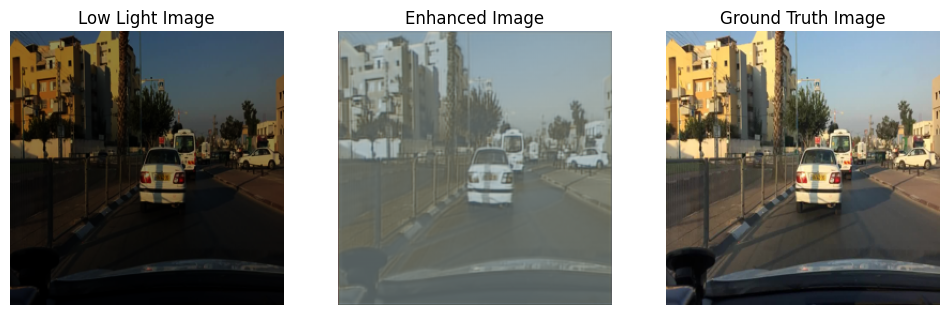

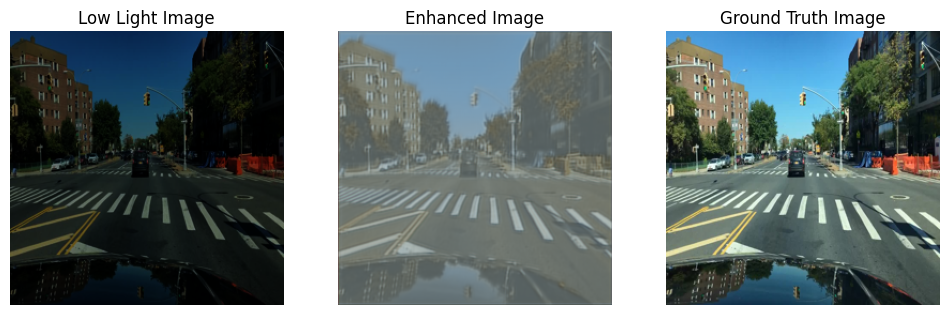

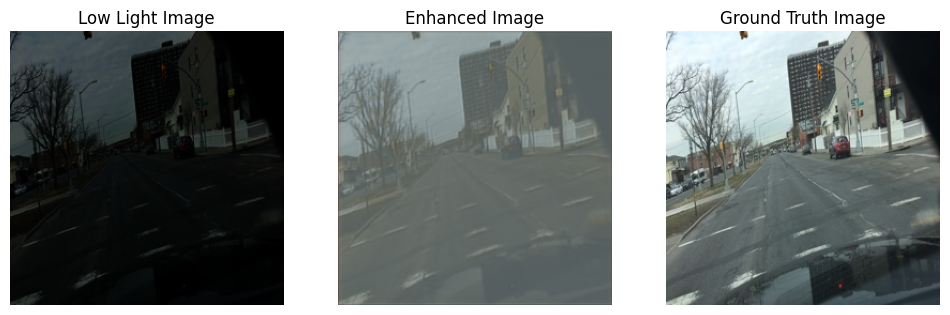

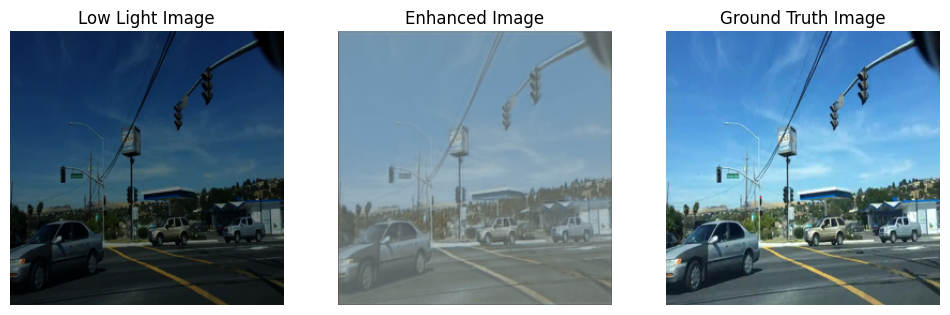

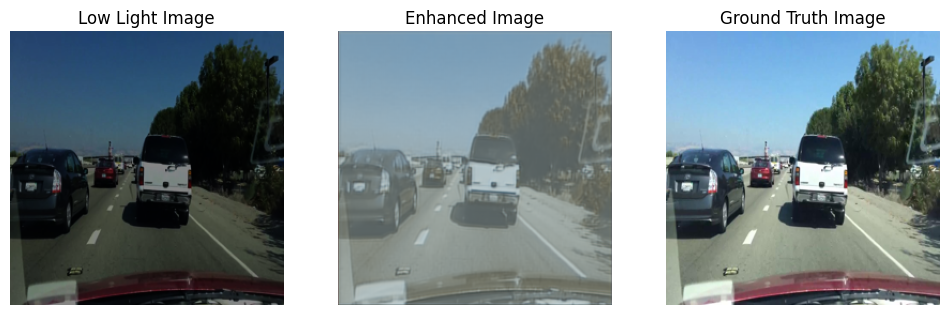

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
loss = evaluate_model(model, test_loader, device)
print(f"Evaluation Loss: {loss}")
draw_images(model, test_loader, device, num_images=5)